# Chapter 185 — Project: Matrix Transformation Playground

> **Prerequisites:** ch151–ch168 (matrices, multiplication, inverse, determinants, linear transformations), ch164 (linear transformations), ch165 (matrix transformation visualization), ch166 (rotations), ch167 (scaling), ch168 (projections)
> **Part VI Project** — Linear Algebra (chapters 151–200)
> **Difficulty:** Intermediate | **Estimated time:** 60–90 minutes
> **Output:** An interactive exploration tool demonstrating how every 2×2 matrix deforms the plane, with decomposition into rotation–scale–rotation (SVD) and connections to eigenstructure

---

## 0. Overview

### Problem Statement

A 2×2 matrix is a function from the plane to the plane. It stretches, rotates, reflects,
shears, and projects — sometimes all at once. The numbers in the matrix encode all of this
geometric behavior, but the encoding is opaque until you visualize it.

This project builds a transformation playground: given any 2×2 matrix, automatically
visualize what it does, decompose it into interpretable parts (SVD), and animate the
continuous transformation from identity to the target.

This is the geometric backbone of computer graphics, robotics, and the visual interpretation
of ML model weight matrices.

### Concepts Used
- Linear transformations *(ch164)*: $T(\mathbf{v}) = \mathbf{M}\mathbf{v}$
- Determinant *(ch158, ch159)*: measures signed area scaling
- Eigenvalues/eigenvectors *(ch169–ch171)*: special fixed directions
- SVD *(ch173)*: $\mathbf{M} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^\top$ — rotation × scale × rotation
- Rotation matrices *(ch166)*, scaling *(ch167)*, projection *(ch168)*

### Expected Output
1. A `visualize_transform` function: before/after for any 2×2 matrix
2. SVD decomposition: show the three-step factorization visually
3. A gallery of canonical transformations
4. Animation: morphing from identity to target matrix
5. Interactive explorer: user specifies matrix entries, sees immediate visual response

---

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from matplotlib.animation import FuncAnimation

plt.style.use('seaborn-v0_8-whitegrid')

# ---------------------------------------------------------------
# Canonical reference objects to transform:
#   - A unit circle (many points, reveals shape deformation)
#   - A unit square (reveals parallelogram collapse)
#   - Basis vectors e1, e2
#   - A simple letter "F" shape (asymmetric, shows orientation)
# ---------------------------------------------------------------

def unit_circle(n=100):
    """Points on the unit circle, shape (2, n)."""
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)
    return np.array([np.cos(theta), np.sin(theta)])


def unit_square():
    """Corners and edges of the unit square [0,1]^2, shape (2, N)."""
    edges = [
        np.column_stack([np.linspace(0,1,20), np.zeros(20)]),    # bottom
        np.column_stack([np.ones(20), np.linspace(0,1,20)]),     # right
        np.column_stack([np.linspace(1,0,20), np.ones(20)]),     # top
        np.column_stack([np.zeros(20), np.linspace(1,0,20)]),    # left
    ]
    pts = np.vstack(edges).T   # shape (2, 80)
    return pts


def letter_F():
    """Points approximating the letter 'F', shape (2, N)."""
    pts = []
    # Vertical stem: x=0..0.2, y=0..1
    for y in np.linspace(0, 1, 30):
        for x in np.linspace(0, 0.2, 5):
            pts.append([x, y])
    # Top bar: x=0..0.8, y=0.8..1
    for x in np.linspace(0, 0.8, 20):
        for y in np.linspace(0.8, 1.0, 5):
            pts.append([x, y])
    # Middle bar: x=0..0.6, y=0.45..0.55
    for x in np.linspace(0, 0.6, 15):
        for y in np.linspace(0.45, 0.55, 3):
            pts.append([x, y])
    pts = np.array(pts).T   # shape (2, N)
    # Center on origin
    pts[0] -= 0.4
    pts[1] -= 0.5
    return pts


CIRCLE = unit_circle(200)
SQUARE = unit_square()
F_SHAPE = letter_F()

print(f"Reference shapes: circle ({CIRCLE.shape}), square ({SQUARE.shape}), F ({F_SHAPE.shape})")

Reference shapes: circle ((2, 200)), square ((2, 80)), F ((2, 295))


---

## 2. Stage 1 — Core Visualization: Before and After

A linear transformation $T(\mathbf{v}) = \mathbf{M}\mathbf{v}$ maps every point
$\mathbf{v}$ in the plane to a new point. Applying it to the circle turns it into an
ellipse. Applying it to the square turns it into a parallelogram. The eigenvectors of
$\mathbf{M}$ are the axes of that ellipse *(ch169)*.

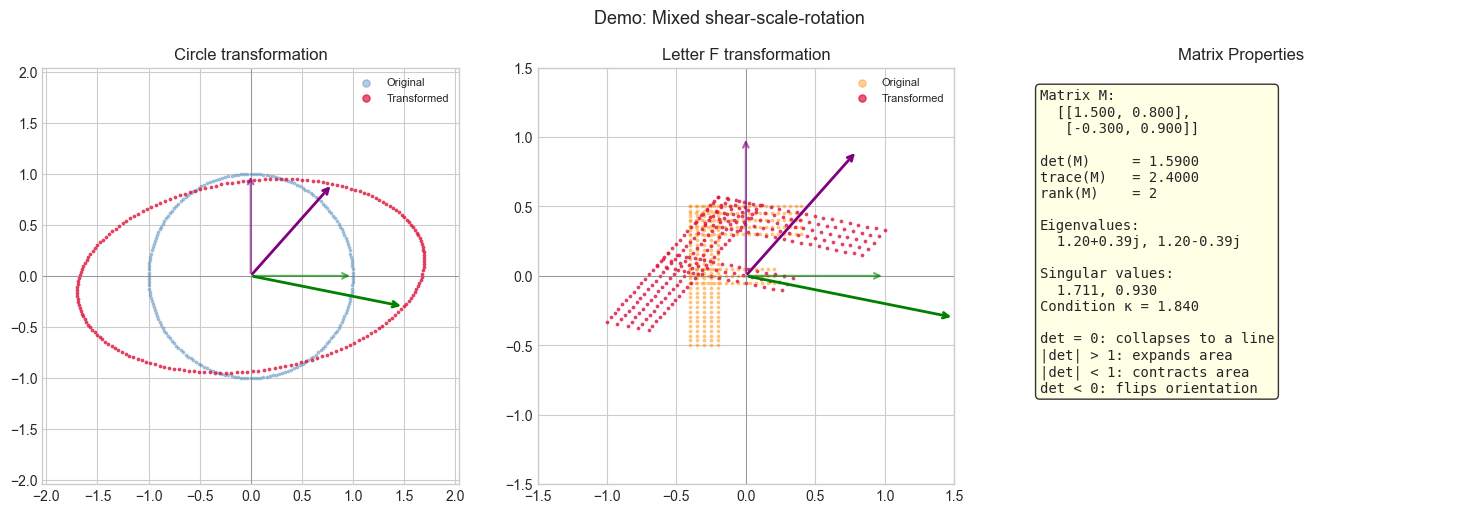

In [2]:
# --- Stage 1: Core Transform Visualizer ---

def apply_transform(M, pts):
    """
    Apply 2x2 matrix M to a set of 2D points.

    Args:
        M:   transformation matrix, shape (2, 2)
        pts: points, shape (2, N)

    Returns:
        Transformed points, shape (2, N)
    """
    return M @ pts   # (2,2) @ (2,N) = (2,N)


def matrix_properties(M):
    """Compute and display key properties of a 2x2 matrix."""
    det      = np.linalg.det(M)
    trace    = np.trace(M)
    rank     = np.linalg.matrix_rank(M)
    vals, _  = np.linalg.eig(M)
    U, S, Vt = np.linalg.svd(M)
    cond     = S[0] / S[-1] if S[-1] > 1e-12 else np.inf
    return {
        'det':    det,
        'trace':  trace,
        'rank':   rank,
        'eigs':   vals,
        'singular_values': S,
        'condition':  cond,
        'U': U, 'Sigma': np.diag(S), 'Vt': Vt
    }


def visualize_transform(M, title=None, show_eigen=True, show_svd_axes=True):
    """
    Full visualization: original → transformed shape, basis vectors, eigenvectors.

    Args:
        M:             2x2 transformation matrix
        title:         optional title
        show_eigen:    overlay eigenvectors
        show_svd_axes: overlay SVD singular vectors
    """
    props = matrix_properties(M)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # --- Shapes: original vs transformed ---
    for ax_idx, (pts, name, color) in enumerate([
        (CIRCLE,  'Circle',  'steelblue'),
        (F_SHAPE, 'Letter F', 'darkorange'),
    ]):
        ax = axes[ax_idx]
        pts_t = apply_transform(M, pts)

        ax.scatter(*pts,   s=3, alpha=0.4, color=color,      label='Original')
        ax.scatter(*pts_t, s=3, alpha=0.7, color='crimson',  label='Transformed')

        # Basis vectors before and after
        origin = np.zeros(2)
        e1, e2 = np.array([1.0, 0]), np.array([0, 1.0])
        for v, col in [(e1, 'green'), (e2, 'purple')]:
            ax.annotate('', xy=v,    xytext=origin,
                        arrowprops=dict(arrowstyle='->', color=col, lw=1.5, alpha=0.6))
            Mv = M @ v
            ax.annotate('', xy=Mv, xytext=origin,
                        arrowprops=dict(arrowstyle='->', color=col, lw=2.0))

        # Eigenvectors (if real)
        if show_eigen:
            evals, evecs = np.linalg.eig(M)
            for i, (ev, vec) in enumerate(zip(evals, evecs.T)):
                if np.isreal(ev):
                    v_scaled = vec.real * 1.2
                    ax.annotate('', xy=v_scaled, xytext=origin,
                                arrowprops=dict(arrowstyle='->', color='gold', lw=2,
                                                linestyle='--'),
                                label=f'λ={ev.real:.2f}')

        all_pts = np.hstack([pts, pts_t])
        lim = max(np.abs(all_pts).max() * 1.2, 1.5)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.axhline(0, color='gray', lw=0.5)
        ax.axvline(0, color='gray', lw=0.5)
        ax.set_aspect('equal')
        ax.set_title(f'{name} transformation')
        ax.legend(markerscale=3, fontsize=8)

    # --- Properties panel ---
    ax3 = axes[2]
    ax3.axis('off')

    eigs = props['eigs']
    eig_str = ', '.join([f'{v:.3f}' if np.isreal(v) else f'{v:.2f}' for v in eigs])
    sv_str  = ', '.join([f'{s:.3f}' for s in props['singular_values']])

    info_text = (
        f"Matrix M:\n"
        f"  [[{M[0,0]:.3f}, {M[0,1]:.3f}],\n"
        f"   [{M[1,0]:.3f}, {M[1,1]:.3f}]]\n\n"
        f"det(M)     = {props['det']:.4f}\n"
        f"trace(M)   = {props['trace']:.4f}\n"
        f"rank(M)    = {props['rank']}\n\n"
        f"Eigenvalues:\n  {eig_str}\n\n"
        f"Singular values:\n  {sv_str}\n"
        f"Condition κ = {props['condition']:.3f}\n\n"
        f"det = 0: collapses to a line\n"
        f"|det| > 1: expands area\n"
        f"|det| < 1: contracts area\n"
        f"det < 0: flips orientation"
    )
    ax3.text(0.05, 0.95, info_text, transform=ax3.transAxes,
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    ax3.set_title('Matrix Properties')

    suptitle = title or f'M = [[{M[0,0]:.2f}, {M[0,1]:.2f}], [{M[1,0]:.2f}, {M[1,1]:.2f}]]'
    plt.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
    plt.show()


# Demo: a shear-scale-rotation
M_demo = np.array([[1.5, 0.8],
                   [-0.3, 0.9]])
visualize_transform(M_demo, title='Demo: Mixed shear-scale-rotation')

---

## 3. Stage 2 — SVD Decomposition: Three Steps Made Visible

Every matrix $\mathbf{M} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^\top$ is a composition
of three transformations *(ch173)*:
1. $\mathbf{V}^\top$: first rotation (into the right singular vector frame)
2. $\boldsymbol{\Sigma}$: axis-aligned scaling by singular values
3. $\mathbf{U}$: second rotation (out of the left singular vector frame)

C:\Users\user\AppData\Local\Temp\ipykernel_28300\1003173248.py:61: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_28300\1003173248.py:61: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


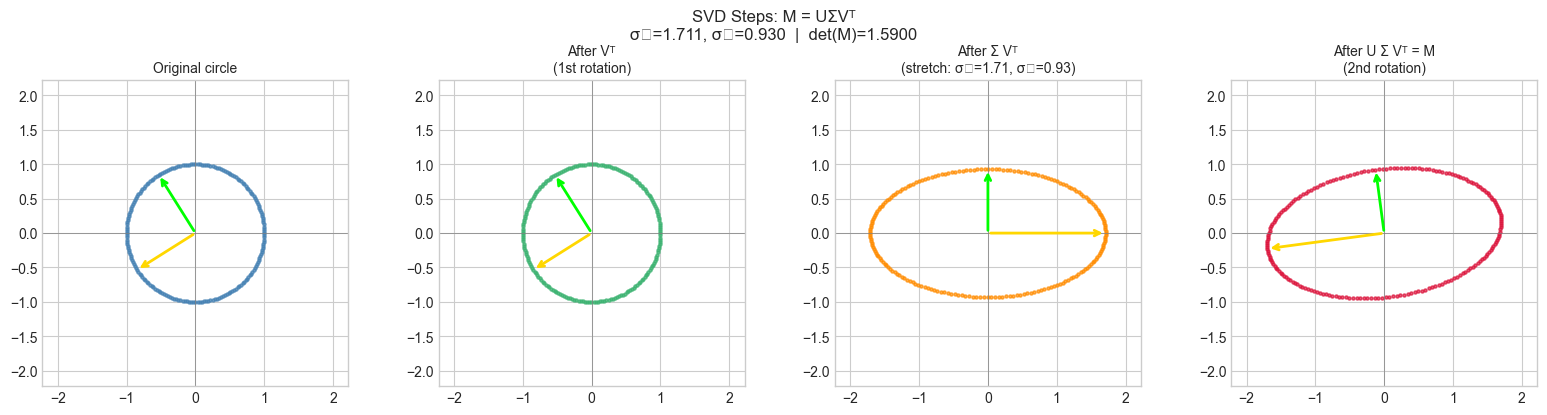

In [3]:
# --- Stage 2: SVD Decomposition — Three Steps ---

def visualize_svd_steps(M):
    """
    Show the three SVD steps: M = U Sigma Vt

    Displays the circle after each partial transformation:
      Step 0: original
      Step 1: after Vt   (rotation)
      Step 2: after Sigma Vt  (stretch, now an axis-aligned ellipse)
      Step 3: after U Sigma Vt = M  (final orientation)
    """
    U, S, Vt = np.linalg.svd(M)
    Sigma = np.diag(S)

    pts0 = CIRCLE.copy()
    pts1 = Vt @ pts0          # rotate to align with singular vectors
    pts2 = Sigma @ pts1       # scale along axes
    pts3 = U @ pts2           # final rotation = M @ pts0

    steps = [
        (pts0, 'Original circle',           'steelblue'),
        (pts1, f'After Vᵀ\n(1st rotation)', 'mediumseagreen'),
        (pts2, f'After Σ Vᵀ\n(stretch: σ₁={S[0]:.2f}, σ₂={S[1]:.2f})', 'darkorange'),
        (pts3, f'After U Σ Vᵀ = M\n(2nd rotation)', 'crimson'),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, (pts, label, color) in zip(axes, steps):
        ax.scatter(*pts, s=5, alpha=0.7, color=color)
        ax.axhline(0, color='gray', lw=0.5)
        ax.axvline(0, color='gray', lw=0.5)
        lim = max(S[0] * 1.3, 1.5)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect('equal')
        ax.set_title(label, fontsize=10)

    # Annotate singular vectors
    origin = np.zeros(2)
    colors_sv = ['gold', 'lime']
    for i, (u_col, v_col, col) in enumerate(zip(U.T, Vt, colors_sv)):
        scale_v = 1.0
        scale_u = S[i]
        # Show V columns on steps 0 and 1
        axes[0].annotate('', xy=v_col * scale_v, xytext=origin,
                          arrowprops=dict(arrowstyle='->', color=col, lw=2))
        axes[1].annotate('', xy=v_col * scale_v, xytext=origin,
                          arrowprops=dict(arrowstyle='->', color=col, lw=2))
        # Show U columns on steps 2 and 3
        axes[2].annotate('', xy=np.array([S[0] if i==0 else 0,
                                           S[1] if i==1 else 0]),
                          xytext=origin,
                          arrowprops=dict(arrowstyle='->', color=col, lw=2))
        axes[3].annotate('', xy=u_col * scale_u, xytext=origin,
                          arrowprops=dict(arrowstyle='->', color=col, lw=2))

    U_str = f'U=[{U[0,0]:.2f},{U[0,1]:.2f};{U[1,0]:.2f},{U[1,1]:.2f}]'
    fig.suptitle(f'SVD Steps: M = UΣVᵀ\nσ₁={S[0]:.3f}, σ₂={S[1]:.3f}  |  det(M)={np.linalg.det(M):.4f}',
                 fontsize=12)
    plt.tight_layout()
    plt.show()


visualize_svd_steps(M_demo)

---

## 4. Stage 3 — Gallery of Canonical Transformations

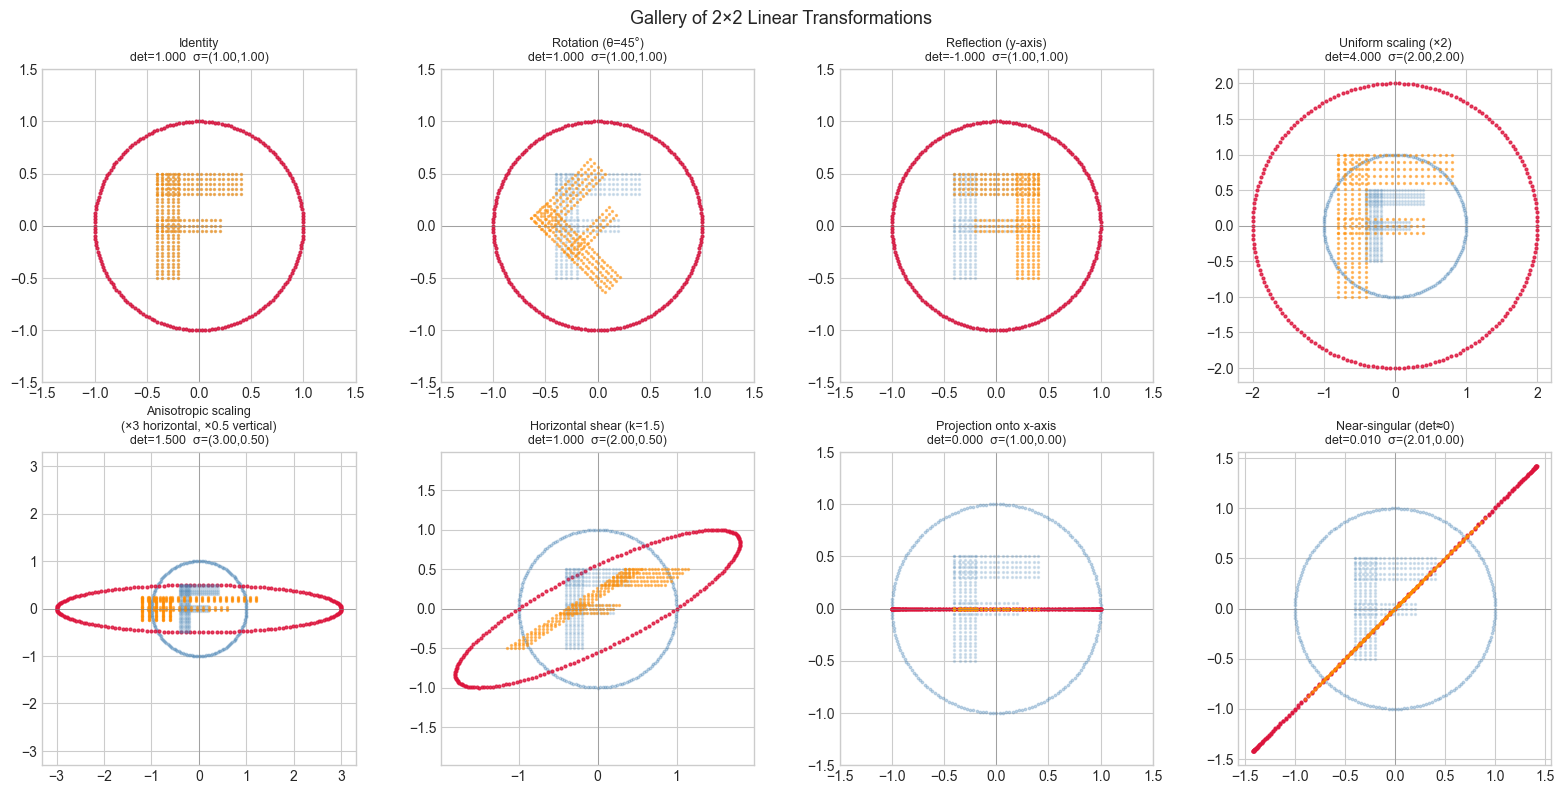

In [4]:
# --- Stage 3: Gallery of Canonical 2x2 Transformations ---
#
# Each transformation has a distinctive signature in its determinant, eigenvalues, and SVD.
# Try changing THETA for rotations, K for shear, s1/s2 for scaling.

THETA = np.pi / 4   # 45 degrees
K     = 1.5         # shear factor

canonical = [
    ('Identity',
     np.eye(2)),

    (f'Rotation (θ={np.degrees(THETA):.0f}°)',
     np.array([[np.cos(THETA), -np.sin(THETA)],
                [np.sin(THETA),  np.cos(THETA)]])),

    ('Reflection (y-axis)',
     np.array([[-1., 0.], [0., 1.]])),

    ('Uniform scaling (×2)',
     2 * np.eye(2)),

    ('Anisotropic scaling\n(×3 horizontal, ×0.5 vertical)',
     np.diag([3.0, 0.5])),

    (f'Horizontal shear (k={K})',
     np.array([[1., K], [0., 1.]])),

    ('Projection onto x-axis',
     np.array([[1., 0.], [0., 0.]])),

    ('Near-singular (det≈0)',
     np.array([[1., 1.], [1., 1.01]])),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes_flat = axes.flatten()

for ax, (name, M) in zip(axes_flat, canonical):
    pts_t = apply_transform(M, CIRCLE)
    F_t   = apply_transform(M, F_SHAPE)

    ax.scatter(*CIRCLE,  s=3, alpha=0.3, color='steelblue')
    ax.scatter(*pts_t,   s=4, alpha=0.8, color='crimson')
    ax.scatter(*F_SHAPE, s=2, alpha=0.2, color='steelblue')
    ax.scatter(*F_t,     s=2, alpha=0.5, color='darkorange')

    det = np.linalg.det(M)
    S   = np.linalg.svd(M, compute_uv=False)

    all_pts = np.hstack([CIRCLE, pts_t, F_SHAPE, F_t])
    lim = min(max(np.abs(all_pts).max() * 1.1, 1.5), 10.0)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', lw=0.4)
    ax.axvline(0, color='gray', lw=0.4)
    ax.set_title(f'{name}\ndet={det:.3f}  σ=({S[0]:.2f},{S[1]:.2f})', fontsize=9)

plt.suptitle('Gallery of 2×2 Linear Transformations', fontsize=13)
plt.tight_layout()
plt.show()

---

## 5. Stage 4 — Animation: Morphing from Identity to Target

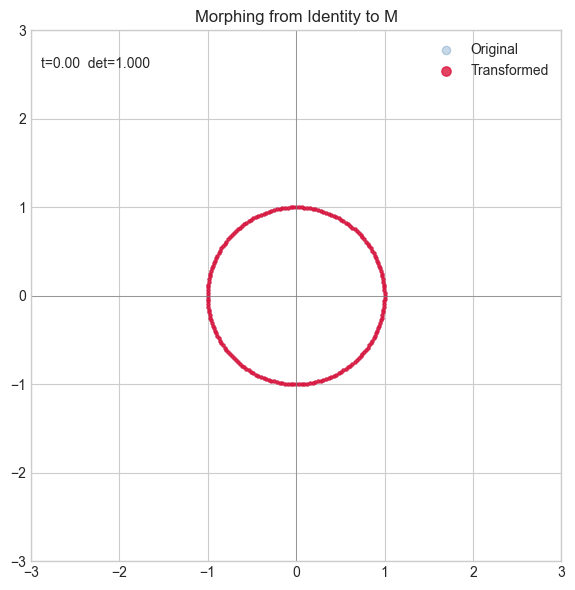

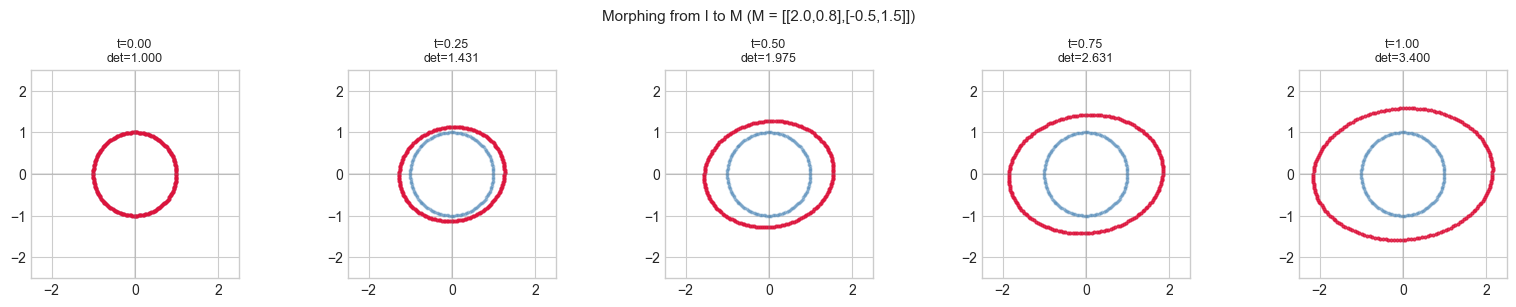

In [5]:
# --- Stage 4: Animated Transformation ---
#
# Interpolate from identity I to target matrix M_target.
# M(t) = (1-t)*I + t*M_target for t in [0, 1]
#
# This is the simplest interpolation — it does NOT preserve rotation structure.
# (A proper interpolation uses matrix logarithm / geodesic — beyond this chapter.)
# Try changing: M_TARGET

M_TARGET = np.array([[2.0, 0.8],
                     [-0.5, 1.5]])

N_FRAMES = 50
ts = np.linspace(0, 1, N_FRAMES)

fig_anim, ax_anim = plt.subplots(figsize=(6, 6))
ax_anim.set_xlim(-3, 3)
ax_anim.set_ylim(-3, 3)
ax_anim.set_aspect('equal')
ax_anim.axhline(0, color='gray', lw=0.5)
ax_anim.axvline(0, color='gray', lw=0.5)
ax_anim.set_title('Morphing from Identity to M')

scat_orig = ax_anim.scatter(*CIRCLE, s=4, alpha=0.3, color='steelblue', label='Original')
scat_tran = ax_anim.scatter(*CIRCLE, s=5, alpha=0.8, color='crimson',   label='Transformed')
det_text  = ax_anim.text(0.02, 0.95, '', transform=ax_anim.transAxes,
                          fontsize=10, verticalalignment='top')
ax_anim.legend(markerscale=3)

def update(frame):
    t = ts[frame]
    M_t = (1 - t) * np.eye(2) + t * M_TARGET
    pts_t = M_t @ CIRCLE
    scat_tran.set_offsets(pts_t.T)
    det = np.linalg.det(M_t)
    det_text.set_text(f't={t:.2f}  det={det:.3f}')
    return scat_tran, det_text

anim = FuncAnimation(fig_anim, update, frames=N_FRAMES,
                     interval=60, blit=True, repeat=True)
plt.tight_layout()
plt.show()

# Still frame summary at t=0, 0.25, 0.5, 0.75, 1.0
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for ax, t in zip(axes, [0.0, 0.25, 0.5, 0.75, 1.0]):
    M_t = (1 - t) * np.eye(2) + t * M_TARGET
    pts_t = M_t @ CIRCLE
    ax.scatter(*CIRCLE, s=3, alpha=0.3, color='steelblue')
    ax.scatter(*pts_t,  s=4, alpha=0.8, color='crimson')
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', lw=0.3)
    ax.axvline(0, color='gray', lw=0.3)
    ax.set_title(f't={t:.2f}\ndet={np.linalg.det(M_t):.3f}', fontsize=9)

plt.suptitle(f'Morphing from I to M (M = [[{M_TARGET[0,0]},{M_TARGET[0,1]}],[{M_TARGET[1,0]},{M_TARGET[1,1]}]])', fontsize=11)
plt.tight_layout()
plt.show()

---

## 6. Results & Reflection

### What Was Built

A complete transformation visualization toolkit:
- `visualize_transform`: shows original/transformed shapes + all matrix properties in one view
- `visualize_svd_steps`: renders the three factored steps of SVD as separate geometric operations
- Gallery of 8 canonical transformations — each with determinant and singular value annotation
- Animated morph: linear interpolation from identity to target matrix

### Geometric–Algebraic Dictionary

| Observable | Algebraic meaning |
|---|---|
| Circle becomes ellipse | Singular values = semi-axes lengths |
| Circle degenerates to line | $\sigma_2 = 0$ (rank deficiency, $\det = 0$) |
| Orientation preserved | $\det > 0$ |
| Orientation flipped | $\det < 0$ (reflection component present) |
| Shape preserving, size changes | $\mathbf{U} = \mathbf{V}$ (both rotations are the same) |
| Eigenvectors visible as fixed axes | Directions stretched but not rotated |

### Extension Challenges

**1. Matrix exponential and smooth morphing.**
Linear interpolation $(1-t)\mathbf{I} + t\mathbf{M}$ is geometrically incoherent for rotations
(it passes through shear-distorted intermediate states).
The correct morphing uses $\mathbf{M}(t) = e^{t\log\mathbf{M}}$ — matrix exponential.
Research `scipy.linalg.logm` and `expm`, implement smooth rotation interpolation, and compare.

**2. Extend to 3D.**
Build a 3D version using matplotlib's `Axes3D`. Transform a unit sphere ($3 \times N$ point
cloud) by a $3 \times 3$ matrix. What does SVD tell you about the transformed ellipsoid's
principal axes? This connects directly to ch186 (3D Transformations).

**3. Composition explorer.**
Build a multi-step playground: apply $\mathbf{M}_1$, then $\mathbf{M}_2$, visualizing both
the intermediate result and the composed matrix $\mathbf{M}_2\mathbf{M}_1$.
Demonstrate that matrix multiplication is not commutative: $\mathbf{M}_1\mathbf{M}_2 \neq \mathbf{M}_2\mathbf{M}_1$.

---

## Summary & Connections

- Every $2 \times 2$ matrix is a **linear map of the plane** — it can rotate, scale, reflect, shear, and project. The determinant measures signed area change; eigenvectors are the fixed directions; SVD decomposes the map into two rotations and a scaling.
- **SVD** $\mathbf{M} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^\top$ is the cleanest geometric reading of a matrix *(ch173)*: $\mathbf{V}^\top$ rotates input space, $\boldsymbol{\Sigma}$ stretches along axes, $\mathbf{U}$ rotates output space. The singular values are the stretch factors.
- The **determinant** is the oriented area of the parallelogram spanned by the matrix's columns — negative det means a reflection, zero det means rank collapse *(ch158–ch159)*.
- This visual intuition directly informs how to read weight matrices in neural networks *(ch177)*: a weight matrix with a large condition number stretches activations unevenly, causing gradient flow problems.

**This project reappears in:**
- *ch186 (Project: 3D Transformations)* — extends this to $3 \times 3$ matrices; homogeneous coordinates; affine transforms in computer graphics.
- *ch219 (Gradient Descent visualization)* — the Hessian matrix at a critical point is exactly a linear transformation of the local loss landscape; its eigenvalues determine whether you're at a minimum, maximum, or saddle.
- *ch165 (Matrix Transformation Visualization)* — the theoretical counterpart to this project, covering the same ground more formally.